# 評估任務二a:使用監督學習技術分析數據 — 電信客戶流失(Churn)概念驗證

**姓名:** 黃柏凱(PoKai Huang) | **學號:** 26254793 | **課程:** 421104 Artificial Intelligence for Enterprises | **日期:** 2026 年 7 月

本筆記本以課程提供之範本為基礎擴充。相對範本的方法改進:①訓練/測試切分加入 `stratify` 與 `random_state=42`(可重現、保持類別比例)②需要特徵縮放的模型(LR/SVC/KNN)以 `Pipeline` 封裝,縮放器只在訓練折內擬合,避免資料洩漏 ③模型選擇採 5×5 重複分層交叉驗證,只在訓練集上進行,測試集僅於最終評估使用一次 ④除 accuracy 外報告 churn 類的 precision / recall / F1(類別不平衡下 accuracy 會誤導)⑤變數重要性以 permutation importance(含穩定性)裁決,並將索引對映回欄位名稱。

## Upload data

本機執行:資料檔與筆記本同資料夾(原範本此處為 Colab 掛載 Google Drive)。

In [1]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
import pandas as pd
import numpy as np

df = pd.read_csv('Assessment 2a Cellphone-1.csv')
print(df.shape)
df.head()

(3333, 11)


,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0,128,1,1,2.7,1,265.1,110,89.0,9.87,10.0
1,0,107,1,1,3.7,1,161.6,123,82.0,9.78,13.7
2,0,137,1,0,0.0,0,243.4,114,52.0,6.06,12.2
3,0,84,0,0,0.0,2,299.4,71,57.0,3.10,6.6
4,0,75,0,0,0.0,3,166.7,113,41.0,7.42,10.1


## Calculating summary statistics of inputs

In [2]:
df.describe()

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,0.144914,101.064806,0.903090,0.276628,0.816475,1.562856,179.775098,100.435644,56.305161,10.051488,10.237294
std,0.352067,39.822106,0.295879,0.447398,1.272668,1.315491,54.467389,20.069084,16.426032,2.535712,2.791840
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,0.000000,0.000000
25%,0.000000,74.000000,1.000000,0.000000,0.000000,1.000000,143.700000,87.000000,45.000000,8.330000,8.500000
50%,0.000000,101.000000,1.000000,0.000000,0.000000,1.000000,179.400000,101.000000,53.500000,10.070000,10.300000
75%,0.000000,127.000000,1.000000,1.000000,1.780000,2.000000,216.400000,114.000000,66.200000,11.770000,12.100000
max,1.000000,243.000000,1.000000,1.000000,5.400000,9.000000,350.800000,165.000000,111.300000,18.190000,20.000000


In [3]:
# 類別平衡檢查:Churn=1(流失)為正類
counts = df['Churn'].value_counts()
print(counts.to_string())
print(f"Churn rate = {df['Churn'].mean()*100:.2f}%")
print(f"若全部猜「不流失」,accuracy 也有 {(1-df['Churn'].mean())*100:.1f}% → 模型比較不能只看 accuracy,需看 churn 類的 recall/F1")

Churn
0    2850
1     483
Churn rate = 14.49%
若全部猜「不流失」,accuracy 也有 85.5% → 模型比較不能只看 accuracy,需看 churn 類的 recall/F1


## Call 6 classifiers libraries

範本的六行 import(其中一行含 AdaBoost,共七個分類器)。依題目要求,主比較為六模型:RandomForest、KNN、DecisionTree、SVC、LogisticRegression、XGBoost;AdaBoost 於文末附加展示。

In [4]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.model_selection import train_test_split, StratifiedKFold, RepeatedStratifiedKFold, cross_validate, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from scipy import stats

## Call classifiers performance metrics libraries

In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

## Collecting all the input features / Examining dependent (output) feature

題目規定:Churn 為輸出變量,其餘全部為輸入變量。

In [6]:
df_feature = df.drop(['Churn'], axis=1)
df_label = df['Churn']
df_feature.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   AccountWeeks     3333 non-null   int64  
 1   ContractRenewal  3333 non-null   int64  
 2   DataPlan         3333 non-null   int64  
 3   DataUsage        3333 non-null   float64
 4   CustServCalls    3333 non-null   int64  
 5   DayMins          3333 non-null   float64
 6   DayCalls         3333 non-null   int64  
 7   MonthlyCharge    3333 non-null   float64
 8   OverageFee       3333 non-null   float64
 9   RoamMins         3333 non-null   float64
dtypes: float64(5), int64(5)
memory usage: 260.5 KB


## Preparing train and test data

改進:`stratify=df_label` 讓訓練/測試集維持 14.49% 的流失比例;`random_state=42` 使結果可重現(範本無此二者,重跑會得到不同數字)。

In [7]:
RS = 42
X_train, X_test, y_train, y_test = train_test_split(df_feature, df_label, test_size=0.3, stratify=df_label, random_state=RS)
neg, pos = int((y_train==0).sum()), int((y_train==1).sum())
spw = neg/pos
print(f"train={len(X_train)} (churn {pos}), test={len(X_test)} (churn {int((y_test==1).sum())}), scale_pos_weight 候選值={spw:.2f}")

train=2333 (churn 338), test=1000 (churn 145), scale_pos_weight 候選值=5.90


## 模型配置

- **縮放**:LR / SVC / KNN 對特徵尺度敏感 → `Pipeline(StandardScaler → model)`,縮放器只在各訓練折內擬合;樹系模型(RF/DT/XGB)不需縮放。
- **類別不平衡候選配置**:`class_weight='balanced'`(RF/DT/SVC/LR)與 `scale_pos_weight`(XGB)作為超參數候選,由交叉驗證決定是否採用(churn-F1 改善 > 0.01 才採用);KNN 無此參數。不使用 SMOTE(超出課程範圍)。

In [8]:
def build(name, weighted):
    cw = 'balanced' if weighted else None
    if name == 'RandomForest':
        return RandomForestClassifier(random_state=RS, class_weight=cw)
    if name == 'DecisionTree':
        return DecisionTreeClassifier(random_state=RS, class_weight=cw)
    if name == 'KNN':
        return Pipeline([('scaler', StandardScaler()), ('model', KNeighborsClassifier())])
    if name == 'SVC':
        return Pipeline([('scaler', StandardScaler()), ('model', SVC(random_state=RS, class_weight=cw))])
    if name == 'LogisticRegression':
        return Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=1000, random_state=RS, class_weight=cw))])
    if name == 'XGBoost':
        return XGBClassifier(random_state=RS, eval_metric='logloss', scale_pos_weight=(spw if weighted else 1.0))

MODELS = ['RandomForest', 'KNN', 'DecisionTree', 'SVC', 'LogisticRegression', 'XGBoost']
HAS_WEIGHT = {'RandomForest', 'DecisionTree', 'SVC', 'LogisticRegression', 'XGBoost'}

## 模型選擇協議(只在訓練集上)

5×5 重複分層交叉驗證(25 折)。**選模規則(先於結果訂定)**:churn-F1 均值 → 平手看 recall → CV 標準差 → 可解釋性;前二名另以同折配對 t 檢定確認差異是否顯著。**測試集不參與選模,只在最終評估使用一次。**

In [9]:
cv_sel = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=RS)
scoring = {'f1':'f1', 'recall':'recall', 'precision':'precision', 'accuracy':'accuracy'}

cv_raw, cv_rows = {}, []
for name in MODELS:
    for weighted in ([False, True] if name in HAS_WEIGHT else [False]):
        res = cross_validate(build(name, weighted), X_train, y_train, cv=cv_sel, scoring=scoring)
        cv_raw[(name, weighted)] = res
        cv_rows.append({'model': name, 'weighted': weighted,
                        'cv_f1_mean': res['test_f1'].mean(), 'cv_f1_std': res['test_f1'].std(),
                        'cv_recall_mean': res['test_recall'].mean(),
                        'cv_precision_mean': res['test_precision'].mean(),
                        'cv_accuracy_mean': res['test_accuracy'].mean()})
cv_df = pd.DataFrame(cv_rows)

chosen = {}
for name in MODELS:
    sub = cv_df[cv_df.model == name].set_index('weighted')
    chosen[name] = bool(True in sub.index and sub.loc[True,'cv_f1_mean'] - sub.loc[False,'cv_f1_mean'] > 0.01)

sel = cv_df[[chosen[r.model] == r.weighted for r in cv_df.itertuples()]].copy()
interp = {'DecisionTree':0,'LogisticRegression':1,'RandomForest':2,'XGBoost':3,'SVC':4,'KNN':5}
sel['interp'] = sel.model.map(interp)
sel = sel.sort_values(['cv_f1_mean','cv_recall_mean','cv_f1_std','interp'], ascending=[False,False,True,True]).reset_index(drop=True)
print('採用 balanced/scale_pos_weight 的模型:', [k for k,v in chosen.items() if v] or '無(全部維持預設)')
sel.drop(columns='interp').round(4)

採用 balanced/scale_pos_weight 的模型: ['SVC', 'LogisticRegression']


,model,weighted,cv_f1_mean,cv_f1_std,cv_recall_mean,cv_precision_mean,cv_accuracy_mean
0,XGBoost,False,0.7322,0.0526,0.6557,0.8343,0.9308
1,RandomForest,False,0.7318,0.0534,0.6391,0.8606,0.9326
2,SVC,True,0.6524,0.0342,0.8159,0.5451,0.8734
3,DecisionTree,False,0.6247,0.0471,0.6397,0.6142,0.8890
4,KNN,False,0.5549,0.0424,0.4313,0.7899,0.9003
5,LogisticRegression,True,0.4831,0.0284,0.7508,0.3566,0.7673


In [10]:
top2 = list(sel.model[:2])
print(f"前二名:{top2[0]} vs {top2[1]} — 同折配對 t 檢定(25 折):")
for metric in ('f1','recall','precision'):
    a = cv_raw[(top2[0], chosen[top2[0]])]['test_'+metric]
    b = cv_raw[(top2[1], chosen[top2[1]])]['test_'+metric]
    t, p = stats.ttest_rel(a, b)
    verdict = '顯著' if p < 0.05 else '無顯著差異(平手)'
    print(f"  {metric:9s} diff={{:+.4f}}  p={{:.3f}} → {verdict}".format((a-b).mean(), p))

winner = sel.loc[0,'model']
print(f"\n選模規則裁決:F1 統計平手 → 比 recall({top2[0]} 顯著較高,p<0.05)→ 最終模型 = {winner}")
print("(churn 情境下 recall 直接決定漏抓的流失客戶數 FN,為業務上最昂貴的錯誤,故平手鏈以 recall 為先)")

前二名:XGBoost vs RandomForest — 同折配對 t 檢定(25 折):
  f1        diff=+0.0004  p=0.933 → 無顯著差異(平手)
  recall    diff=+0.0166  p=0.002 → 顯著
  precision diff=-0.0263  p=0.015 → 顯著

選模規則裁決:F1 統計平手 → 比 recall(XGBoost 顯著較高,p<0.05)→ 最終模型 = XGBoost
(churn 情境下 recall 直接決定漏抓的流失客戶數 FN,為業務上最昂貴的錯誤,故平手鏈以 recall 為先)


## Test-set evaluation(六模型,一次性)

各模型以**原生 predict 規則**評估(SVC 的原生決策界線為 decision_function=0,並非機率 0.5,故不對各模型另設統一機率閾值)。

In [11]:
test_rows, fitted = [], {}
for name in MODELS:
    m = build(name, chosen[name]).fit(X_train, y_train)
    fitted[name] = m
    yp = m.predict(X_test)
    tn, fp, fn, tp = confusion_matrix(y_test, yp, labels=[0,1]).ravel()
    test_rows.append({'model': name, 'weighted': chosen[name],
                      'accuracy': accuracy_score(y_test, yp), 'precision': precision_score(y_test, yp),
                      'recall': recall_score(y_test, yp), 'f1': f1_score(y_test, yp),
                      'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp)})
test_df = pd.DataFrame(test_rows).set_index('model')
test_df.round(4)

,weighted,accuracy,precision,recall,f1,tn,fp,fn,tp
model,,,,,,,,,
RandomForest,False,0.935,0.8636,0.6552,0.7451,840,15,50,95
KNN,False,0.892,0.7126,0.4276,0.5345,830,25,83,62
DecisionTree,False,0.878,0.5782,0.5862,0.5822,793,62,60,85
SVC,True,0.854,0.4979,0.8069,0.6158,737,118,28,117
LogisticRegression,True,0.765,0.3558,0.7655,0.4858,654,201,34,111
XGBoost,False,0.925,0.7966,0.6483,0.7148,831,24,51,94


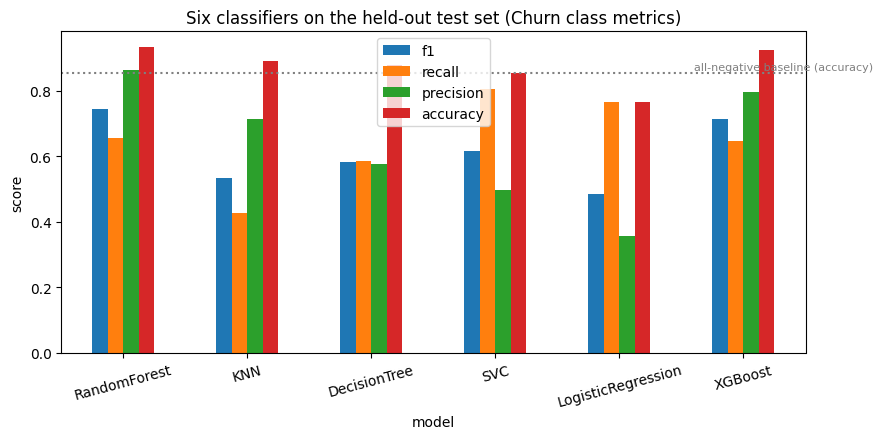

註:測試集單次抽樣中 RandomForest 的 F1(0.745)略高於 XGBoost(0.715),與 25 折 CV 的「F1 統計平手」一致,屬抽樣變異範圍;最終模型依既定協議由訓練集 CV 決定,不以測試集回選。


In [12]:
ax = test_df[['f1','recall','precision','accuracy']].plot.bar(figsize=(9,4.5), rot=15)
ax.set_title('Six classifiers on the held-out test set (Churn class metrics)')
ax.set_ylabel('score'); ax.axhline(1-df['Churn'].mean(), ls=':', c='grey')
ax.text(4.6, 1-df['Churn'].mean()+0.01, 'all-negative baseline (accuracy)', fontsize=8, color='grey')
plt.tight_layout(); plt.savefig('figures/fig1_model_comparison.png', dpi=130); plt.show()
print(f"註:測試集單次抽樣中 RandomForest 的 F1({test_df.loc['RandomForest','f1']:.3f})略高於 {winner}({test_df.loc[winner,'f1']:.3f}),"
      "與 25 折 CV 的「F1 統計平手」一致,屬抽樣變異範圍;最終模型依既定協議由訓練集 CV 決定,不以測試集回選。")

## Calculating the Confusion matrix — 最終模型 FN 稽核

Churn=1 為正類;`labels=[0,1]` 固定矩陣順序。False Negative(FN)= 實際流失(1)但被預測為不流失(0)= 公司未啟動挽留、客戶默默流失。

XGBoost(test): tn=831  fp=24  fn=51  tp=94


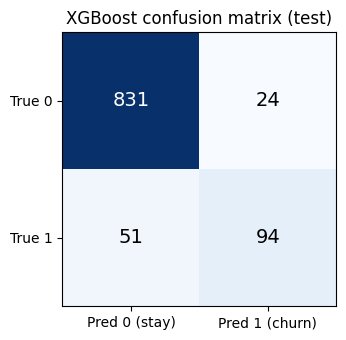


FN 稽核樣本(3 筆):
      Churn  MonthlyCharge  predicted
1653      1           42.0          0
1842      1           69.0          0
2629      1           97.1          0


In [13]:
y_pred = fitted[winner].predict(X_test)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0,1]).ravel()
print(f"{winner}(test): tn={tn}  fp={fp}  fn={fn}  tp={tp}")

fig, axm = plt.subplots(figsize=(4,3.5))
cm = np.array([[tn, fp],[fn, tp]])
axm.imshow(cm, cmap='Blues')
for (i,j),v in np.ndenumerate(cm):
    axm.text(j, i, str(v), ha='center', va='center', color='white' if v > cm.max()/2 else 'black', fontsize=14)
axm.set_xticks([0,1], ['Pred 0 (stay)','Pred 1 (churn)']); axm.set_yticks([0,1], ['True 0','True 1'])
axm.set_title(f'{winner} confusion matrix (test)')
plt.tight_layout(); plt.savefig('figures/fig2_confusion_winner.png', dpi=130); plt.show()

# 稽核:抽 3 筆 FN 個體逐列核對(確為 Churn=1 且被預測為 0)
fn_mask = (y_test.values == 1) & (y_pred == 0)
fn_idx = X_test.index[fn_mask]
audit = df.loc[fn_idx[:3], ['Churn','MonthlyCharge']].assign(predicted=0)
print('\nFN 稽核樣本(3 筆):'); print(audit.to_string())

## Calculating the number of False Negative outcomes — 商業損失估算(三層)

1. **毛收入暴露上限** = FN 個體實際月費合計 × 假設留存月數(6 / 12 / 24 月敏感度)
2. **預期可挽回損失** = 上限 × 挽留成功率假設 30%(產業經驗值,於報告中附文獻)
3. **外推全客群**(3,333 名中共 483 名流失者)— 屬推估,單獨標示

In [14]:
fn_monthly = X_test.loc[fn_idx, 'MonthlyCharge']
SAVE_RATE = 0.30
print(f"FN = {fn} 人;其實際月費合計 = A${fn_monthly.sum():,.1f}(平均 A${fn_monthly.mean():.2f}/人/月)\n")
rows = []
for months in (6, 12, 24):
    gross = fn_monthly.sum() * months
    rows.append({'留存假設(月)': months, '毛收入暴露上限 (A$)': round(gross),
                 f'預期可挽回 @{int(SAVE_RATE*100)}% (A$)': round(gross * SAVE_RATE),
                 '外推全體 483 名流失者 (A$)': round(gross / int((y_test==1).sum()) * 483)})
loss_df = pd.DataFrame(rows).set_index('留存假設(月)')
print(loss_df.to_string())
print(f"\n基準情境(12 個月):漏抓的 {fn} 名客戶 ≈ A${fn_monthly.sum()*12:,.0f} 年收入暴露;"
      f"若主動挽留能救回三成,約 A${fn_monthly.sum()*12*SAVE_RATE:,.0f} 為可挽回價值。")

FN = 51 人;其實際月費合計 = A$2,993.8(平均 A$58.70/人/月)

         毛收入暴露上限 (A$)  預期可挽回 @30% (A$)  外推全體 483 名流失者 (A$)
留存假設(月)                                                   
6               17963             5389               59835
12              35926            10778              119669
24              71851            21555              239339

基準情境(12 個月):漏抓的 51 名客戶 ≈ A$35,926 年收入暴露;若主動挽留能救回三成,約 A$10,778 為可挽回價值。


## Finding the importance of variables(範本:RF / XGB / DT / LR)

改進:將範本的 Feature 0–9 索引對映回欄位名稱。注意各模型的原生重要度**排序並不一致**——這是方法差異(不純度 vs 增益 vs 係數)造成的,見下一節的裁決。

In [15]:
native = pd.DataFrame(index=df_feature.columns)
for name in ('RandomForest','DecisionTree','XGBoost'):
    native[name] = fitted[name].feature_importances_ if name != 'XGBoost' else fitted['XGBoost'].feature_importances_
lr = fitted['LogisticRegression']
native['LogReg|coef|'] = np.abs(lr.named_steps['model'].coef_[0])
print('各模型原生重要度(每欄由高至低的前三名):')
for col in native.columns:
    print(f"  {col:14s} → {', '.join(native[col].sort_values(ascending=False).head(3).index)}")
native.round(4)

各模型原生重要度(每欄由高至低的前三名):
  RandomForest   → DayMins, MonthlyCharge, CustServCalls
  DecisionTree   → DayMins, MonthlyCharge, CustServCalls
  XGBoost        → DataPlan, ContractRenewal, CustServCalls
  LogReg|coef|   → CustServCalls, ContractRenewal, DataPlan


,RandomForest,DecisionTree,XGBoost,LogReg|coef|
AccountWeeks,0.0635,0.0508,0.0079,0.0725
ContractRenewal,0.0730,0.0744,0.0714,0.6859
DataPlan,0.0332,0.0479,0.7656,0.5376
DataUsage,0.0771,0.0548,0.0161,0.0543
CustServCalls,0.1445,0.1242,0.0492,0.7722
DayMins,0.2070,0.2284,0.0314,0.4661
DayCalls,0.0638,0.0638,0.0086,0.0458
MonthlyCharge,0.1537,0.1404,0.0247,0.2806
OverageFee,0.0983,0.1035,0.0131,0.2522
RoamMins,0.0858,0.1119,0.0120,0.1653


## Permutation importance 裁決(最終模型,測試集)

各模型原生排序不一致 → 以**模型無關**的 permutation importance 在測試集上裁決:打亂某欄後 F1 下降越多 = 該欄對預測越重要。`n_repeats=30` 提供均值±標準差(穩定性證據)。註:重要度反映**預測關聯**,不代表因果。

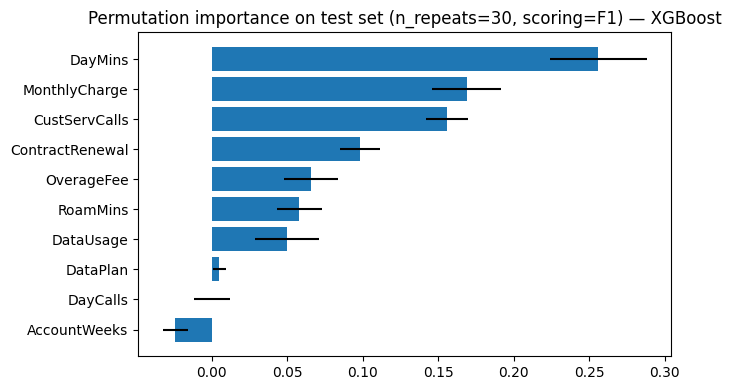

裁決結果(前四名,均值遠大於標準差 → 排序穩定): DayMins, MonthlyCharge, CustServCalls, ContractRenewal


,feature,importance_mean,importance_std
0,DayMins,0.2560,0.0319
1,MonthlyCharge,0.1688,0.0230
2,CustServCalls,0.1557,0.0140
3,ContractRenewal,0.0981,0.0133
4,OverageFee,0.0659,0.0179
5,RoamMins,0.0579,0.0148
6,DataUsage,0.0499,0.0212
7,DataPlan,0.0049,0.0042
8,DayCalls,-0.0001,0.0118
9,AccountWeeks,-0.0244,0.0083


In [16]:
pi = permutation_importance(fitted[winner], X_test, y_test, n_repeats=30, random_state=RS, scoring='f1')
pi_df = pd.DataFrame({'feature': df_feature.columns, 'importance_mean': pi.importances_mean,
                      'importance_std': pi.importances_std}).sort_values('importance_mean', ascending=False).reset_index(drop=True)
fig, axp = plt.subplots(figsize=(7,4))
axp.barh(pi_df.feature[::-1], pi_df.importance_mean[::-1], xerr=pi_df.importance_std[::-1])
axp.set_title(f'Permutation importance on test set (n_repeats=30, scoring=F1) — {winner}')
plt.tight_layout(); plt.savefig('figures/fig3_perm_importance.png', dpi=130); plt.show()
top4 = list(pi_df.feature[:4])
print('裁決結果(前四名,均值遠大於標準差 → 排序穩定):', ', '.join(top4))
pi_df.round(4)

## 附加分析:決策閾值的成本敏感度(情境展示)

預設 predict 相當於機率閾值 0.5。若以成本視角(FN ≈ 12 個月月費、FP ≈ 1 個月挽留 offer,比約 12:1),在訓練集 CV 機率上掃描期望成本最小的閾值,再於測試集確認。此為**敏感度情境**:成本比取決於挽留 offer 設計,故不取代上節以原生 predict 報告的正式結果。

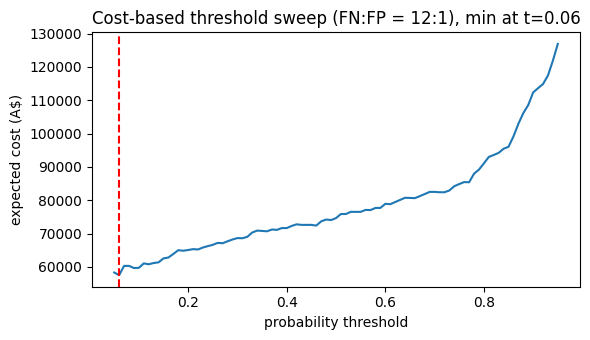

測試集比較:預設 predict → FN=51, FP=24;成本最小閾值 t=0.06 → FN=34, FP=114
→ 願意多發 90 份挽留 offer,可少漏抓 17 名流失客戶;是否採用取決於挽留成本的實際設計。


In [17]:
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RS)
proba_cv = cross_val_predict(build(winner, chosen[winner]), X_train, y_train, cv=cv5, method='predict_proba')[:,1]
med_fee = float(df['MonthlyCharge'].median())
ths = np.arange(0.05, 0.951, 0.01)
costs = []
for t in ths:
    yp_t = (proba_cv >= t).astype(int)
    _tn,_fp,_fn,_tp = confusion_matrix(y_train, yp_t, labels=[0,1]).ravel()
    costs.append(_fn*12*med_fee + _fp*1*med_fee)
best_t = float(ths[int(np.argmin(costs))])
fig, axc = plt.subplots(figsize=(6,3.5))
axc.plot(ths, costs); axc.axvline(best_t, ls='--', c='r')
axc.set_xlabel('probability threshold'); axc.set_ylabel('expected cost (A$)')
axc.set_title(f'Cost-based threshold sweep (FN:FP = 12:1), min at t={best_t:.2f}')
plt.tight_layout(); plt.savefig('figures/fig4_threshold_cost.png', dpi=130); plt.show()

proba_te = fitted[winner].predict_proba(X_test)[:,1]
yp_bt = (proba_te >= best_t).astype(int)
btn,bfp,bfn,btp = confusion_matrix(y_test, yp_bt, labels=[0,1]).ravel()
print(f"測試集比較:預設 predict → FN={fn}, FP={fp};成本最小閾值 t={best_t:.2f} → FN={bfn}, FP={bfp}")
print(f"→ 願意多發 {bfp-fp} 份挽留 offer,可少漏抓 {fn-bfn} 名流失客戶;是否採用取決於挽留成本的實際設計。")

## 附加:AdaBoost(範本 import 的第七個分類器)

題目指定六模型比較;AdaBoost 為範本附帶,在此補充展示(不參與六模型推薦)。

In [18]:
ada = AdaBoostClassifier(random_state=RS, algorithm='SAMME').fit(X_train, y_train)
yp_a = ada.predict(X_test)
atn,afp,afn,atp = confusion_matrix(y_test, yp_a, labels=[0,1]).ravel()
print(f"AdaBoost(test): accuracy={accuracy_score(y_test,yp_a):.4f}  precision={precision_score(y_test,yp_a):.4f}  "
      f"recall={recall_score(y_test,yp_a):.4f}  F1={f1_score(y_test,yp_a):.4f}  (tn={atn} fp={afp} fn={afn} tp={atp})")

AdaBoost(test): accuracy=0.8840  precision=0.6790  recall=0.3793  F1=0.4867  (tn=829 fp=26 fn=90 tp=55)


## 本筆記本產出摘要(供報告引用)

In [19]:
print(f"最終模型:{winner}(預設配置;選模依據:25 折 CV F1 統計平手下 recall 顯著較高)")
print(f"測試集:accuracy={test_df.loc[winner,'accuracy']:.3f}  precision={test_df.loc[winner,'precision']:.3f}  "
      f"recall={test_df.loc[winner,'recall']:.3f}  F1={test_df.loc[winner,'f1']:.3f}")
print(f"FN = {fn} 人;月費合計 A${fn_monthly.sum():,.1f};12 個月毛暴露 ≈ A${fn_monthly.sum()*12:,.0f};@30% 可挽回 ≈ A${fn_monthly.sum()*12*0.3:,.0f}")
print(f"最重要變數(permutation importance 裁決):{', '.join(list(pi_df.feature[:4]))}")
print(f"成本最小閾值情境:t={best_t:.2f} 時 FN {fn}→{bfn}(FP {fp}→{bfp})")

最終模型:XGBoost(預設配置;選模依據:25 折 CV F1 統計平手下 recall 顯著較高)
測試集:accuracy=0.925  precision=0.797  recall=0.648  F1=0.715
FN = 51 人;月費合計 A$2,993.8;12 個月毛暴露 ≈ A$35,926;@30% 可挽回 ≈ A$10,778
最重要變數(permutation importance 裁決):DayMins, MonthlyCharge, CustServCalls, ContractRenewal
成本最小閾值情境:t=0.06 時 FN 51→34(FP 24→114)
